This code connects your Google Drive to Google Colab, so you can read and save files directly in Colab.

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This step imports all required libraries and sets key parameters such as dataset path, image size, batch size, and random seed for consistent results.

In [65]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

DATASET_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_lab_activities/Assets/Insects_dataset'
BATCH_SIZE = 32
SEED = 123
IMG_SIZE = (224, 224)

Step 1: Load dataset and split into train/validation

This step loads our insect image dataset and splits it into 80% training data and 20% validation data. It also identifies the three insect classes we are using.

In [24]:
print("Loading dataset with 80/20 train-validation split...")

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")

Loading dataset with 80/20 train-validation split...
Found 514 files belonging to 2 classes.
Using 412 files for training.
Found 514 files belonging to 2 classes.
Using 102 files for validation.
Classes found: ['Train_data', 'test_data']


Step2: Optimize dataset performance

This step optimizes the dataset loading speed using prefetching, making training faster and more efficient.

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Step 3: Data Augmentation

Data augmentation is used to apply random horizontal flips, rotations, and zooms to training images. This increases data variety and helps prevent the model from overfitting. Sample augmented images are displayed to show the effect.

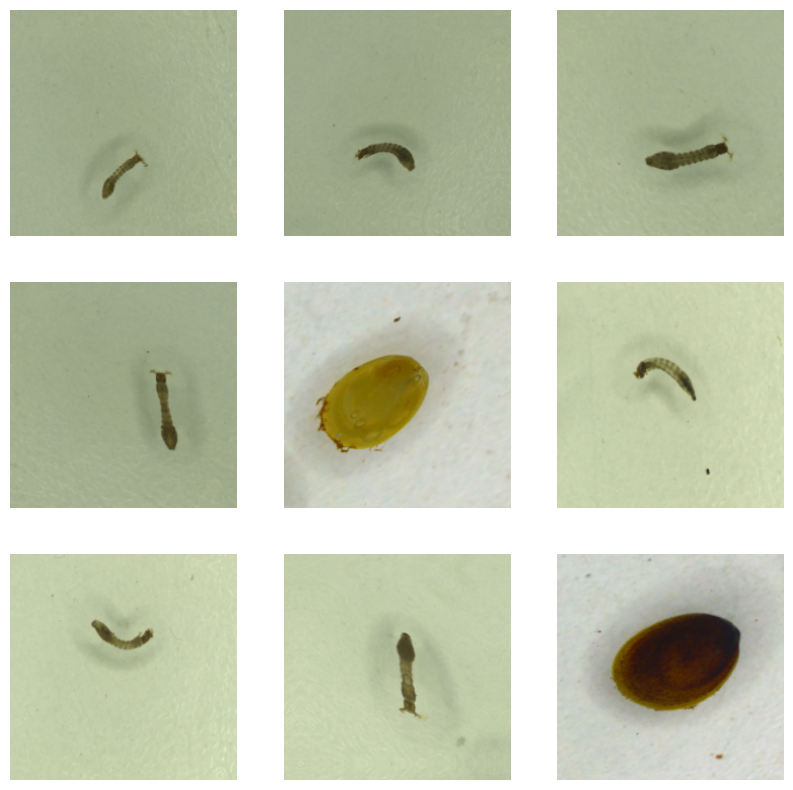

In [30]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        plt.subplot(3, 3, i+1)
        plt.imshow(augmented[i].numpy().astype("uint8"))
        plt.axis("off")
plt.show()

Step 4:Build transfer

This step builds a transfer learning model using MobileNetV2. We freeze the pre-trained base model, add data augmentation, preprocessing, global average pooling, dropout, and a final classification layer, then compile the model with Adam optimizer and sparse categorical crossentropy loss.

In [31]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

STEP 5: Train the model

This step trains the compiled transfer learning model on the augmented insect dataset. We use the training and validation datasets to fit the model, and store the training history for later performance analysis.

In [39]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9854 - loss: 0.0536 - val_accuracy: 0.9706 - val_loss: 0.2072
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9879 - loss: 0.0421 - val_accuracy: 0.9706 - val_loss: 0.2135
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9854 - loss: 0.0400 - val_accuracy: 0.9608 - val_loss: 0.2161
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9879 - loss: 0.0325 - val_accuracy: 0.9608 - val_loss: 0.2199
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9830 - loss: 0.0400 - val_accuracy: 0.9608 - val_loss: 0.2240
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9879 - loss: 0.0453 - val_accuracy: 0.9608 - val_loss: 0.2254
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9951 - loss: 0.0188 - val_accuracy: 0.9608 - val_loss: 0.2257
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9879 - loss: 0.0370 - val_accuracy: 0.9608 - val_loss:

STEP 6: Plot training

After training the model, we visualize the training and validation performance curves to analyze the model's learning process. This step plots the accuracy and loss values across all training epochs, allowing us to evaluate how well the model generalizes to unseen validation data, identify potential overfitting or underfitting, and assess the overall effectiveness of the transfer learning approach for our insect classification task.

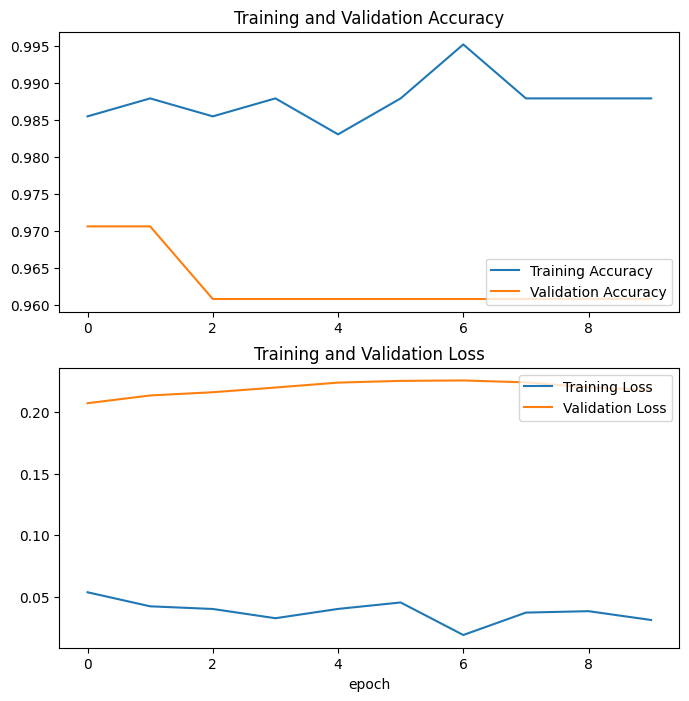

In [41]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

STEP 7: Fine-tune the model

In this step, we perform fine-tuning to further improve model performance. We unfreeze the top layers of the pre-trained MobileNetV2 base model, recompile the model with a smaller learning rate, and continue training to adapt the high-level features to our insect classification dataset.

Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9903 - loss: 0.0221 - val_accuracy: 0.9608 - val_loss: 0.2117
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9927 - loss: 0.0247 - val_accuracy: 0.9608 - val_loss: 0.2152
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9951 - loss: 0.0142 - val_accuracy: 0.9608 - val_loss: 0.2181
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9951 - loss: 0.0139 - val_accuracy: 0.9608 - val_loss: 0.2144
Epoch 14/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9976 - loss: 0.0112 - val_accuracy: 0.9608 - val_loss: 0.2106
Epoch 15/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9927 - loss: 0.0136 - val_accuracy: 0.9608 - val_loss: 0.2067
Epoch 16/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9927 - loss: 0.0150 - val_accuracy: 0.9608 - val_loss: 0.2055
Epoch 17/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9927 - loss: 0.0190 - val_accuracy: 0.9608 - v

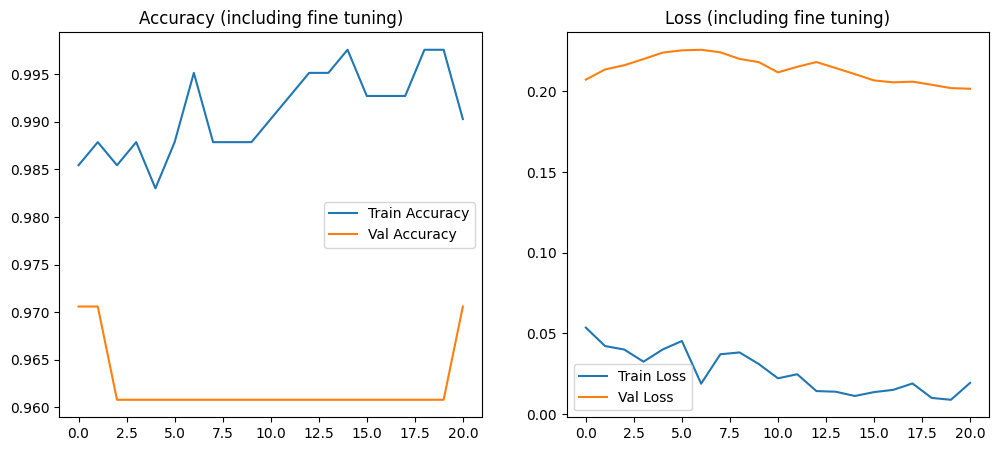

In [43]:
base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)

acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy (including fine tuning)')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss (including fine tuning)')

plt.show()

Step 8: Prediction on new images

This code runs inference on a test image with the trained EfficientNet model: it preprocesses the image, predicts its class and confidence, then displays the result.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


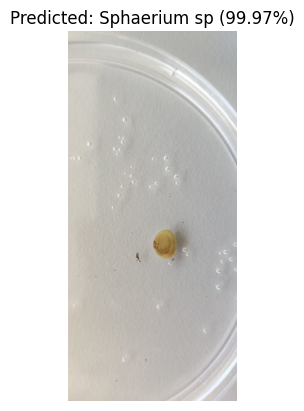

In [67]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    return img_array

def predict_image(img_path, model, class_names):
    img_array = load_and_preprocess_image(img_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]
    return class_names[pred_idx], confidence

test_img_path = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_lab_activities/Assets/Insects_dataset/test_data/Sphaerium sp/CPH-Sphaerium sp.-2805-t.png'

predicted_class, confidence = predict_image(test_img_path, model, class_names)

plt.imshow(image.load_img(test_img_path))
plt.axis('off')
plt.title(f'Predicted: {predicted_class} ({confidence * 100:.2f}%)')
plt.show()

This code evaluates the performance of the trained image classification model using multiple metrics. It collects true labels and predictions from the validation set, generates a confusion matrix to visualize classification accuracy, computes precision, recall, and F1-score for quantitative assessment, and plots ROC curves with AUC values to measure the model’s ability to distinguish between classes. Together, these metrics validate the model’s reliability and generalization ability.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


<Figure size 800x800 with 0 Axes>

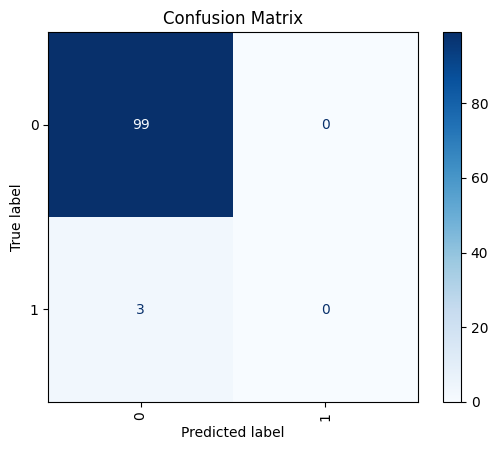

<Figure size 1200x1200 with 0 Axes>

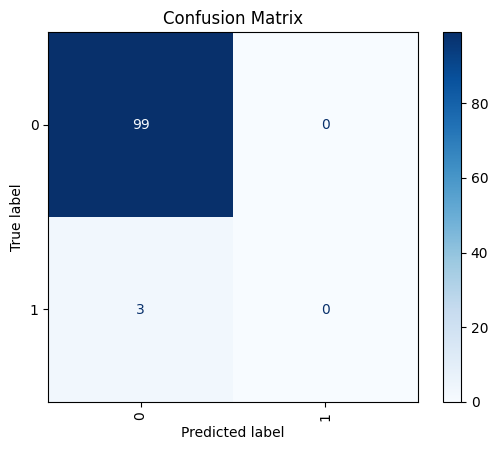

Precision: 0.9420
Recall: 0.9706
F1-score: 0.9561


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


IndexError: index 2 is out of bounds for axis 1 with size 2

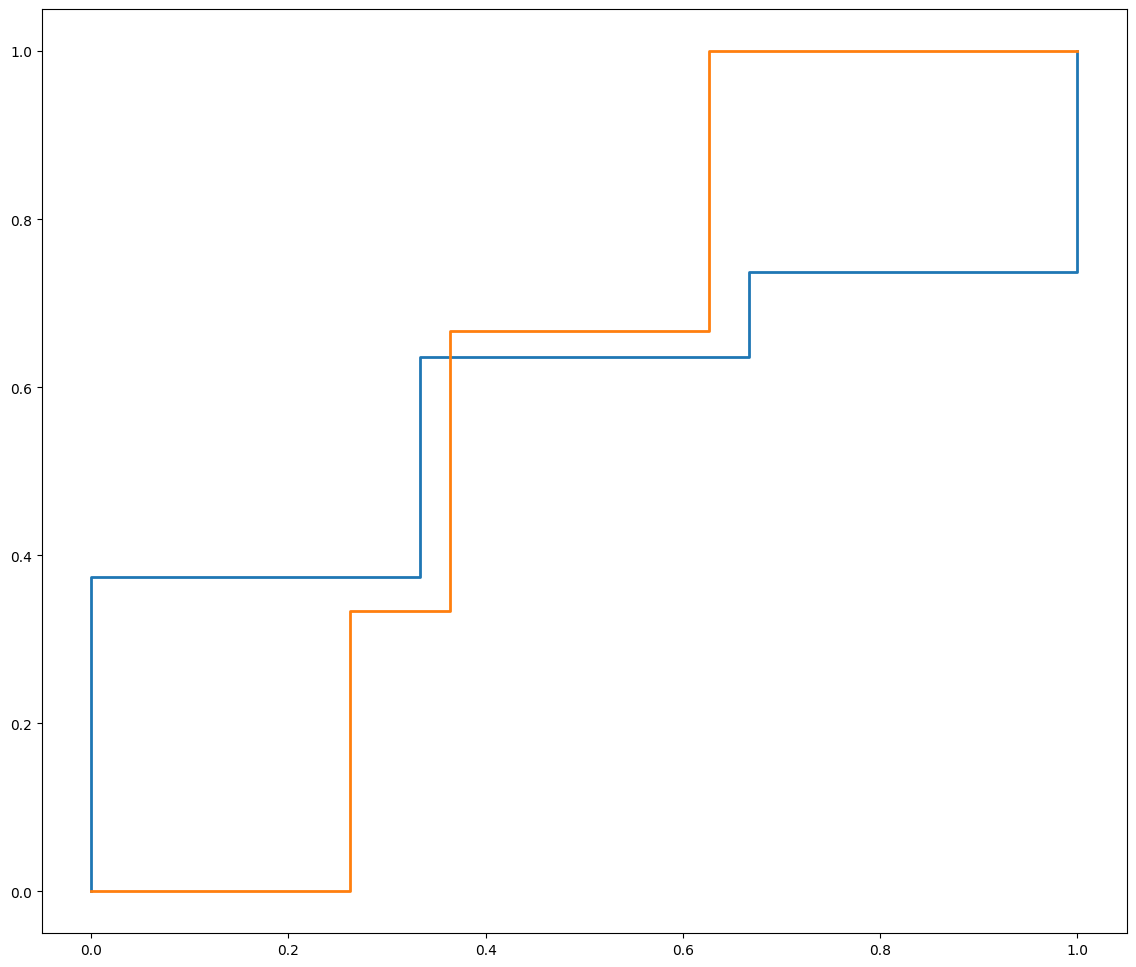

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm = confusion_matrix(y_true, y_pred)
fixed_labels = [str(i) for i in range(cm.shape[0])]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)

plt.figure(figsize=(8,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


<Figure size 1200x1200 with 0 Axes>

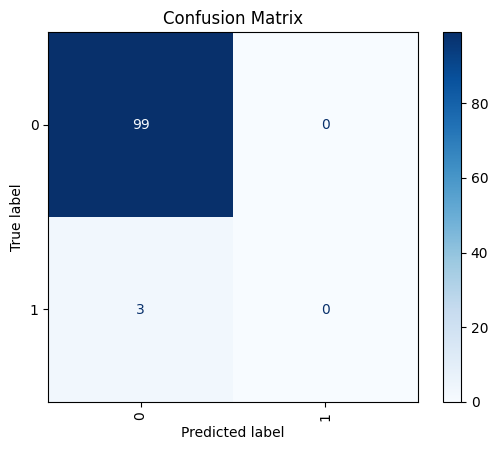

Precision: 0.9420
Recall: 0.9706
F1-score: 0.9561


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


IndexError: index 2 is out of bounds for axis 1 with size 2

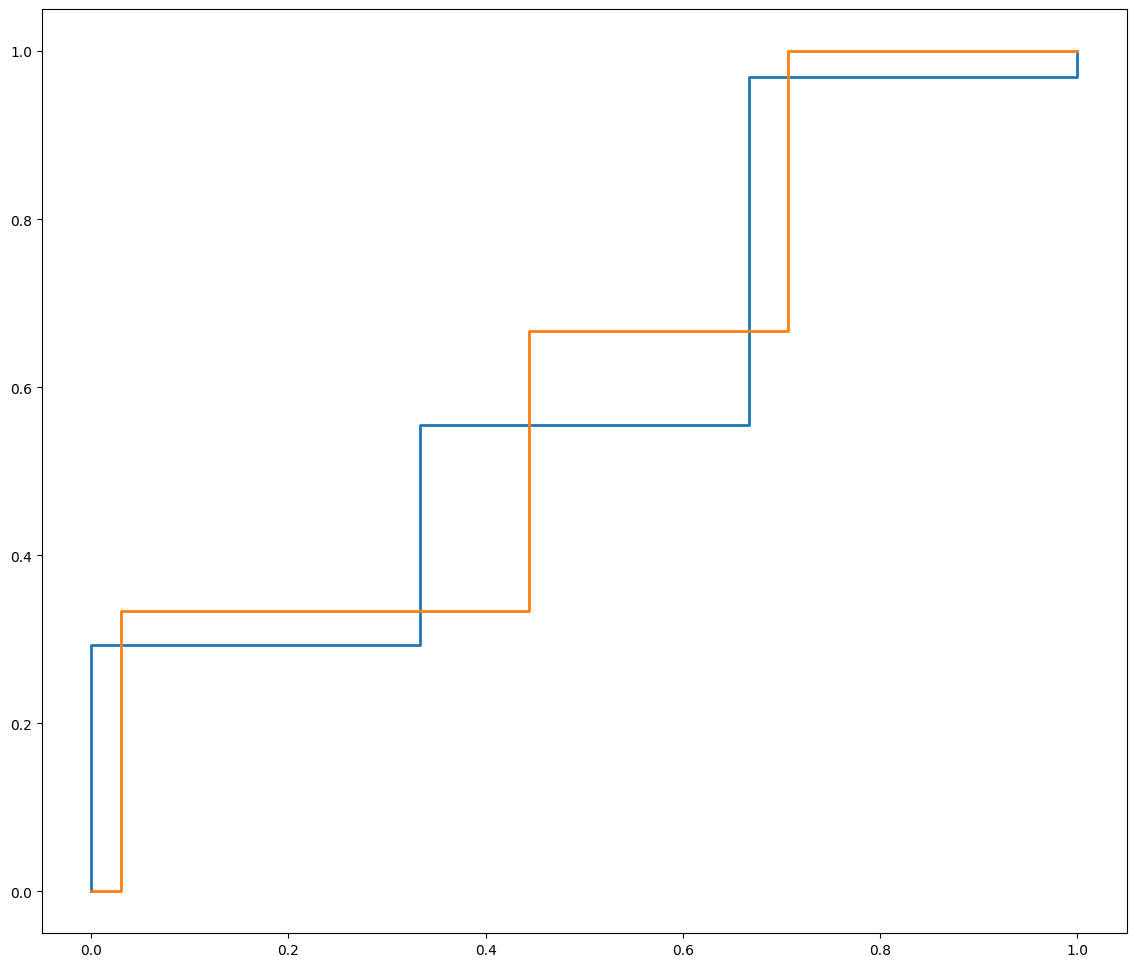

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm = confusion_matrix(y_true, y_pred)
fixed_labels = [str(i) for i in range(cm.shape[0])]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)

plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

n_classes = len(class_names)
real_classes = np.unique(y_true)
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = len(class_names)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.show()

Step12:

This step performs inference on unseen test images. It loads and preprocesses images from the test dataset, uses the trained model to predict their classes, and outputs the prediction results with confidence scores, allowing evaluation of the model's performance on new, unseen data

Running inference on images from 'test_images' folder...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Original Image: CPH-Sphaerium sp.-2804-t.png --> Predicted: Sphaerium sp (99.99%)


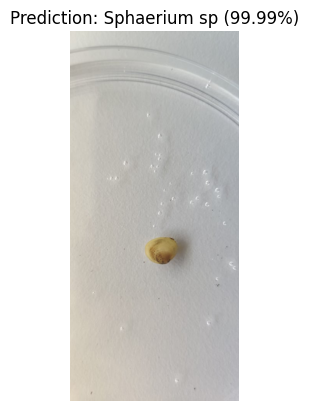

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Original Image: CPH-Sphaerium sp.-2805-t.png --> Predicted: Sphaerium sp (99.99%)


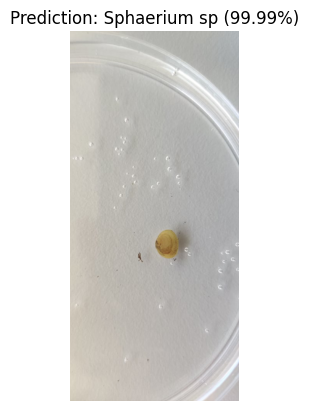

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Original Image: CPH-Sialis sp.-2410-t.png --> Predicted: Sphaerium sp (99.99%)


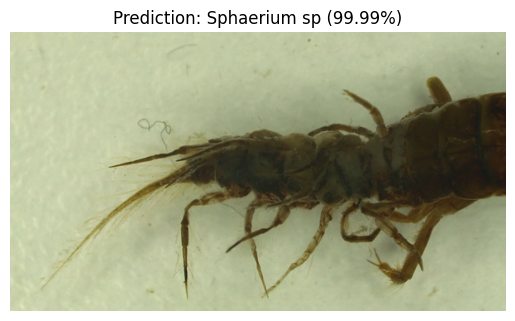

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Original Image: CPH-Sialis sp.-2409-t.png --> Predicted: Sphaerium sp (99.99%)


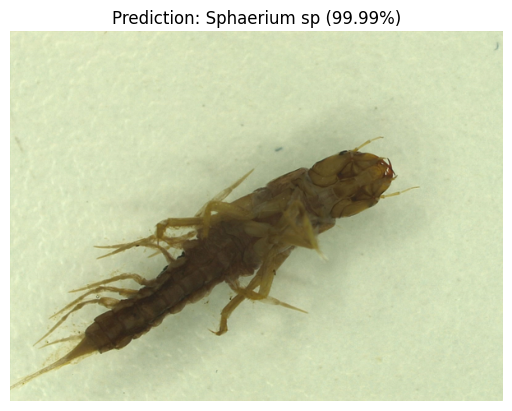

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Original Image: CPH-Sialis sp.-2411-t.png --> Predicted: Sphaerium sp (99.99%)


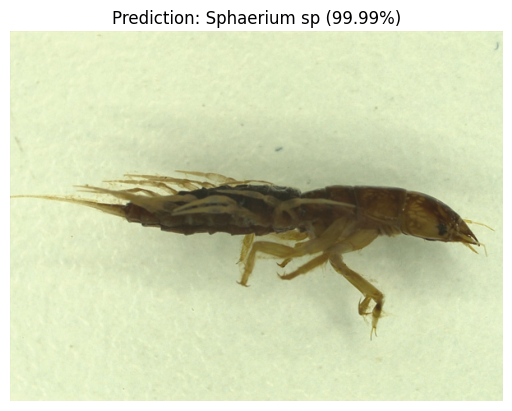

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Original Image: CPH-Sialis sp.-2412-t.png --> Predicted: Sphaerium sp (99.99%)


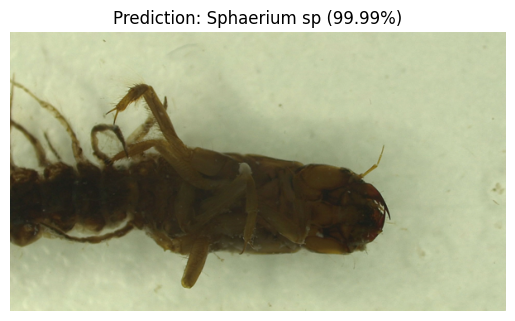

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Original Image: CPH-Sialis sp.-2408-t.png --> Predicted: Sphaerium sp (99.99%)


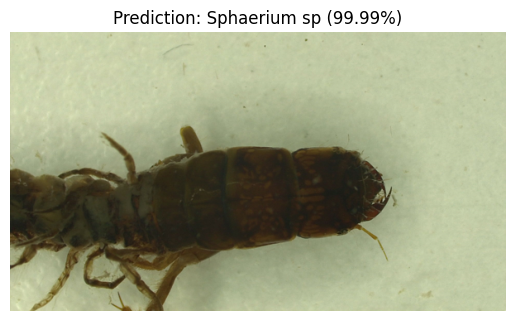

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Original Image: CPH-Simuliidae sp.-2430-t.png --> Predicted: Sphaerium sp (99.99%)


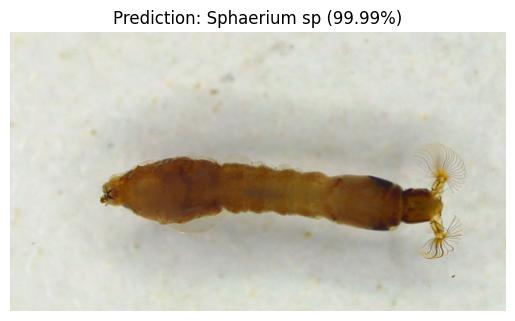

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Original Image: CPH-Simuliidae sp.-2431-t.png --> Predicted: Sphaerium sp (99.99%)


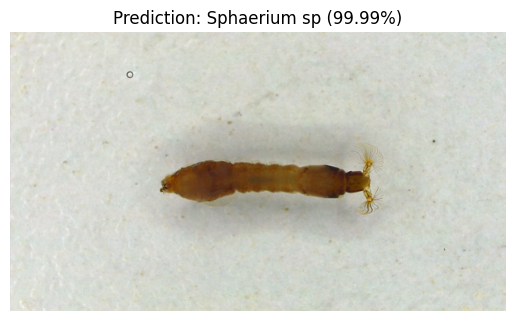

In [83]:
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_lab_activities/Assets/Insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predict_new_images(test_dir):
    for class_folder in os.listdir(test_dir):
        folder_path = os.path.join(test_dir, class_folder)
        if not os.path.isdir(folder_path):
            continue
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                path = os.path.join(folder_path, img_file)
                img_arr = load_and_preprocess_image(path)
                preds = model.predict(img_arr)
                pred_idx = np.argmax(preds[0])
                confidence = preds[0][pred_idx]

                print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")

                img = image.load_img(path)
                plt.imshow(img)
                plt.axis('off')
                plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
                plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)